In [5]:
from math import factorial
from collections import Counter

def distinct_permutations(s):
    counts = Counter(s)
    denom = 1
    for cnt in counts.values():
        denom *= factorial(cnt)
    return factorial(len(s)) // denom

s1 = "Тимощук"
s2 = "Максим"
s3 = s1 + s2

res = {
    "Фамилия": distinct_permutations(s1),
    "Имя": distinct_permutations(s2),
    "Имя и фамилия": distinct_permutations(s3)
}

print(res)

{'Фамилия': 5040, 'Имя': 720, 'Имя и фамилия': 778377600}


Описательная статистика для всех 100 значений:
  Среднее (mean): -1.6768
  Медиана (median): -2.1176
  Стандартное отклонение (std): 21.7167
  Минимум (min): -35.5969
  Максимум (max): 36.0427

Доверительные интервалы для 36 чётных значений:
  95% CI: [-8.9834, 6.2483]
  99% CI: [-11.3764, 8.6414]


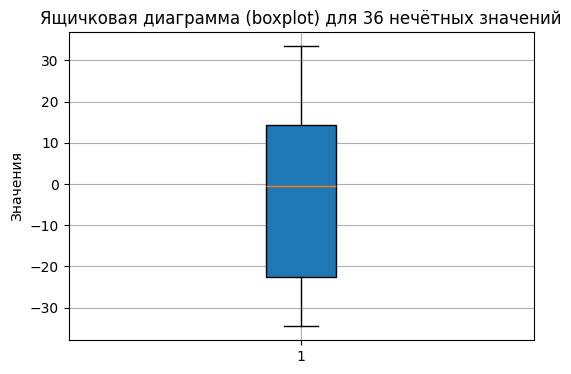

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)  # фиксируем seed для воспроизводимости (можно убрать или заменить на другую цифру, работает как номер набора конкретного датасета)
data = np.random.uniform(low=-36, high=37, size=100)
df = pd.DataFrame(data, columns=['values'])
mean_value = df['values'].mean()    # Среднее
median_value = df['values'].median()  # Медиана
std_value = df['values'].std()      # Стандартное отклонение
min_value = df['values'].min()      # Минимум
max_value = df['values'].max()      # Максимум
print("Описательная статистика для всех 100 значений:")
print(f"  Среднее (mean): {mean_value:.4f}")
print(f"  Медиана (median): {median_value:.4f}")
print(f"  Стандартное отклонение (std): {std_value:.4f}")
print(f"  Минимум (min): {min_value:.4f}")
print(f"  Максимум (max): {max_value:.4f}")

# Разделение на чётные и нечётные по целой части, если floor(x) % 2 == 0 → число идёт в "чётные", иначе → в "нечётные". (вообще можно было считать чётные и нечётные индексы, а не сами значения, но думаю нет особой разницы)

even_values = [x for x in data if int(np.floor(x)) % 2 == 0]
odd_values  = [x for x in data if int(np.floor(x)) % 2 != 0]
data_even_36 = even_values[:36]
data_odd_36  = odd_values[:36]
if len(data_even_36) < 36 or len(data_odd_36) < 36:
    print("Предупреждение: в одной из групп меньше 36 значений!")
def confidence_interval(data_array, confidence=0.95):
    n = len(data_array)
    mean_ = np.mean(data_array)
    std_ = np.std(data_array, ddof=1)  
    z = stats.norm.ppf((1 + confidence) / 2)
    margin_error = z * (std_ / np.sqrt(n))
    return mean_ - margin_error, mean_ + margin_error
if len(data_even_36) >= 2:  # чтобы можно было что-то посчитать
    ci_95_even = confidence_interval(data_even_36, confidence=0.95)
    ci_99_even = confidence_interval(data_even_36, confidence=0.99)
    print("\nДоверительные интервалы для 36 чётных значений:")
    print(f"  95% CI: [{ci_95_even[0]:.4f}, {ci_95_even[1]:.4f}]")
    print(f"  99% CI: [{ci_99_even[0]:.4f}, {ci_99_even[1]:.4f}]")
else:
    print("\nНедостаточно чётных значений для расчёта доверительных интервалов.")
if len(data_odd_36) > 0:
    plt.figure(figsize=(6, 4))
    plt.boxplot(data_odd_36, vert=True, patch_artist=True)
    plt.title("Ящичковая диаграмма (boxplot) для 36 нечётных значений")
    plt.ylabel("Значения")
    plt.grid(True)
    plt.show()
else:
    print("\nНедостаточно нечётных значений для построения boxplot.")